# Quick Start

Molass Library is designed to achieve the following motto:

> Easy things should be easy, and hard things should be possible.

which is a quote from Larry Wall, the creator of the Perl language.
Although Perl gave way to Python and we will use Python, this motto is ubiquitous in software library design.

In this chapter, we will show the easy part to give an idea of what it is all about.
If the input data are well conditioned, this will suffice to get what you expect in an ordinary use.
However, life is not so easy. That is why the hard part exists, which we provide in the later chapters.

## Installation

We assume you have already installed Python and you are familiar with [Jupyter Notebook](https://en.wikipedia.org/wiki/Project_Jupyter#Jupyter_Notebook).

To install the Molass Library package, you can use pip as follows:

```console
pip install -U molass
pip install -U molass_data
```

```{note}
The molass_data package includes a data set for this tutorial.
```

## Tools for Jupyter Notebooks

For programming in Jupyter Notebooks, we recommend either of the following tools (other alternatives are also possible):

* [Jupyter Lab](https://jupyter.org/)
* [Jupyter Extension in VS Code](https://code.visualstudio.com/docs/datascience/jupyter-notebooks)


## Straight Usage
### Plot the Input Data

We can plot the data set as follows. The format of this data set is specified in the chapter 4 of [MOLASS User's Guide](https://pfwww.kek.jp/saxs/software/MOLASS-UsersGuide-1_0_13.pdf).


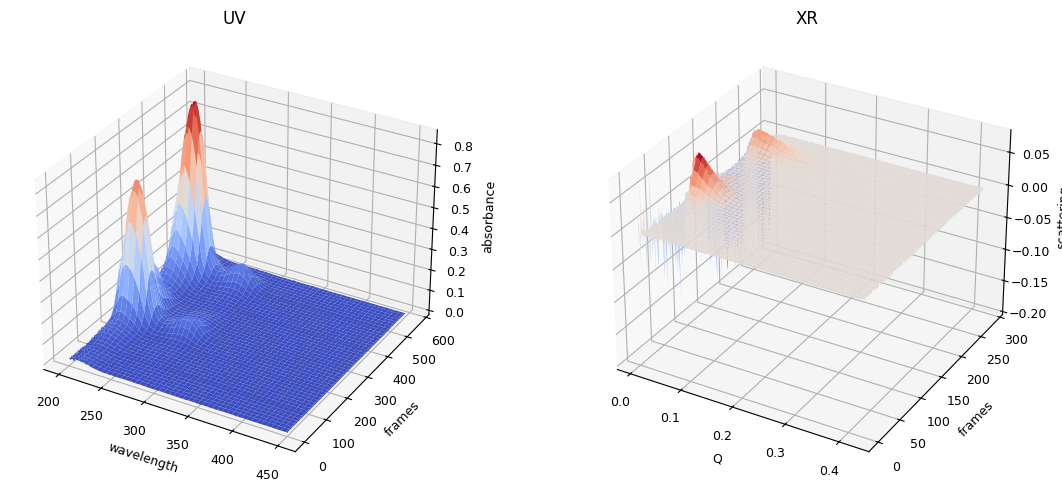

In [1]:
from molass_data import TUTORIAL_DATA
from molass.DataObjects import SecSaxsData as SSD
ssd = SSD(TUTORIAL_DATA)
ssd.plot_3d();

### Trimming, Correction and LRF

For simplisity, we assume here the data set contains two components because we observe two chromatographic peaks ignorinig the bump observed in the right side of the first peak.
To get a set of well-estimated scattering curves of each component, we usually need to apply these three steps, namely, trimming, baseline corection, and LRF - low rank factorization.
We can execute these steps and show the result as follows. The details of each step will be explained in later chapters.

developper memo: remember that "LowRank.CoupledAdjuster.select_components" is not implemented yet.


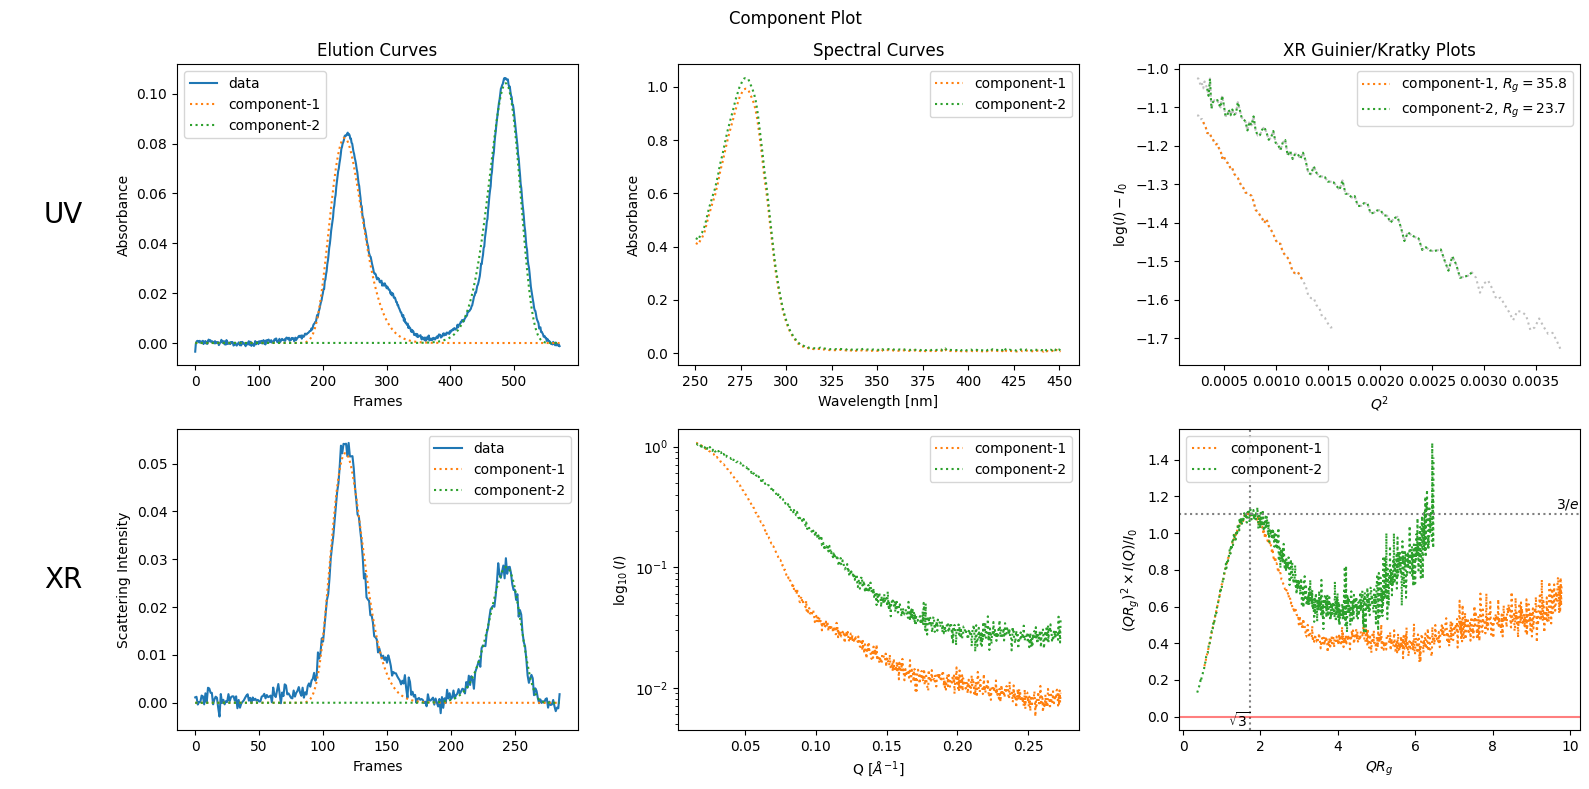

In [2]:
trimmed_ssd = ssd.trimmed_copy()
corrected_ssd = trimmed_ssd.corrected_copy()
lrf_info = corrected_ssd.quick_lowrank_info()
lrf_info.plot_components() 

### Running DENSS

From the result of LRF, which is expressed as "lrf_info" in the python code, we can obntain scattering curve data of each component.
Once you have a well-conditioned scattering curve, you can reconstruct the electron density distribution using an appropriate SAXS tool.
In Molass Library, you can use [DENSS](https://tdgrant.com/) derectly as follows.

In [3]:
from molass.SAXS.DenssTools import run_denss
jcurve_array = lrf_info.get_xr_components()[0].get_jcurve_array()
output_folder = "temp"
run_denss(jcurve_array, output_folder=output_folder)

Dmax = 129.43
Number of experimental Shannon channels: 11
Number of calculated Shannon channels: 33


 Step     Chi2     Rg    Support Volume
 ----- --------- ------- --------------
  620   1.73e-02  61.57        1240768            
switched to shrinkwrap by density threshold = 0.2000
  999   6.30e-05  36.15        351729          EC: 1 -> 1 
 2095   2.69e-05  36.46        304609          

### Plotting the DENSS result

The DENSS result can be visualized as follows.

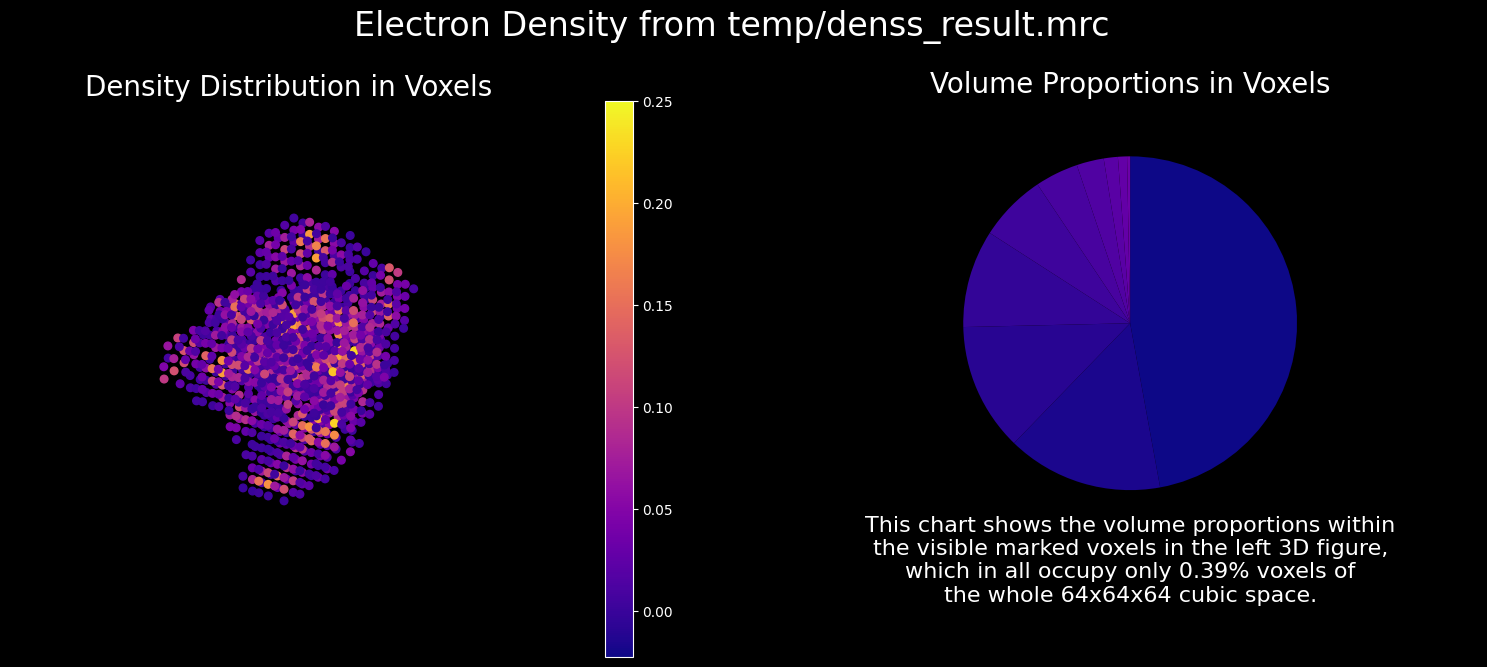

In [4]:
import matplotlib.pyplot as plt
from molass.SAXS.MrcViewer import show_mrc
# %matplotlib widget
%matplotlib inline
show_mrc(output_folder + '/denss_result.mrc');